BatchNorm과 Gradient 안정성
- Minibatch 크기의 영향
- Batch Normalization의 효과
- Gradient 안정성 비교

독립적으로 실행 가능합니다.

In [20]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 재현성을 위한 시드 고정
torch.manual_seed(42)
np.random.seed(42)

In [21]:
# 모델
class SimpleNet(nn.Module):
    # BatchNorm 없는 기본 신경망
    def __init__(self):
        super(SimpleNet, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(20, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid() # 이진 분류 (1 OR 0)
          )
    def forward(self, x):
        return self.network(x)

In [22]:
# 데이터셋 준비

#make_classification으로 가상의 이진 분류 데이터셋 생성
# n_samples=1000: 샘플 1000개, n_features=20: 특성 20개
# n_informative=15: 실제 클래스 구분에 유의미한 특성 15개
# n_redundant=5: 유의미한 특성들의 선형결합으로 만든 중복(가짜) 특성 5개
# random_state=42: 재현성을 위한 난수 시드 고정
X, y = make_classification(n_samples=1000, n_features=20, n_informative=15, n_redundant =5, random_state=42)



In [23]:
# 데이터 분할
# 전체 데이터를 80% 훈련 / 20% 테스트로 무작위 분할
# random_state=42로 매번 같은 결과가 나오도록 고정
# stratify=y로 훈련셋과 테스트셋 모두 원본과 동일한 클래스 비율을 유지하게 함 → 클래스 불균형으로 인한 평가 왜곡 방지
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42, stratify=y)

In [24]:
X_test[:2] # 그냥 3번째 열 데이터 찍어봄

array([[ -3.32850077,  -2.20018002,  -0.20749963,  -1.45740886,
         -2.00767193,  -1.25821794,  -1.05411   ,   0.94484676,
          2.96747447,  -0.14390068,  -1.35274829,   5.14232672,
         -2.05572016,   0.69347055,   1.28456823,   0.35083878,
         -1.13756615,   1.04340086,   1.71733973,   0.40017656],
       [-12.91713343,   1.68276426,   2.62480941,  -1.99204428,
         -3.49840499,   2.42561544,  -0.15679461,  -1.04321382,
          4.23602846,   1.39591086,   3.94483847,   2.12406715,
         -0.65757175,  -6.26439163,  -1.80475942,  -7.0266726 ,
          2.74265732,  -0.16545511,   2.36397325,   1.77271933]])

In [25]:
# 표준화
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)
X_test[:2]


array([[-0.60858769, -0.9032934 , -0.25736403, -0.39641458, -0.93604574,
        -0.28460758, -0.84973987,  0.21186128,  1.22998051,  0.062552  ,
        -0.704827  ,  0.95271546, -0.80638597,  0.55817104,  0.43139994,
         0.31474277, -0.35068998,  0.43169854,  0.82874762,  0.10002424],
       [-2.19236257, -0.12537678,  0.95671321, -0.61871046, -1.53375456,
         1.24120848, -0.42852487, -0.73067074,  1.73068238,  0.67484096,
         1.67498647,  0.36948206, -0.25469631, -1.97808453, -0.81021452,
        -0.99411235,  1.22366272,  0.20177632,  1.06997042,  0.56177325]])

In [40]:
# tensor로 변형
x_train_t = torch.FloatTensor(X_train)
x_test_t = torch.FloatTensor(X_test)
print(x_train_t.shape)

torch.Size([800, 20])


In [33]:
torch.FloatTensor(y_train)
torch.FloatTensor(y_train).shape

torch.Size([800])

In [34]:
torch.FloatTensor(y_train).unsqueeze(1).shape

torch.Size([800, 1])

In [41]:
y_train_t = torch.FloatTensor(y_train).unsqueeze(1)

In [36]:
# 다양한 배치 Batch size 학습
batch_sizes = [8,32,128,512]
criterion = nn.BCELoss()

In [42]:
batch_size_results = []

for bs in batch_sizes:
  dataset = TensorDataset(x_train_t, y_train_t)
  dataloader = DataLoader(dataset=dataset, batch_size=bs, shuffle=True)

  model = SimpleNet()
  optimizer = optim.Adam(model.parameters(), lr=0.001)

  losses =[]
  num_epochs = 5

  for epoch in range(num_epochs):
    epoch_loss = 0
    for batch_x, batch_y in dataloader:
      model.train()
      optimizer.zero_grad()

      output = model(batch_x)
      loss = criterion(output, batch_y)

      loss.backward()
      optimizer.step()

      epoch_loss += loss.item()

    avg_loss = epoch_loss / len(dataloader)
    losses.append(avg_loss)

  batch_size_results.append((bs, losses))
  print(f'최종손실: {losses[-1]:.4f}')



최종손실: 0.1435
최종손실: 0.2819
최종손실: 0.5862
최종손실: 0.6493


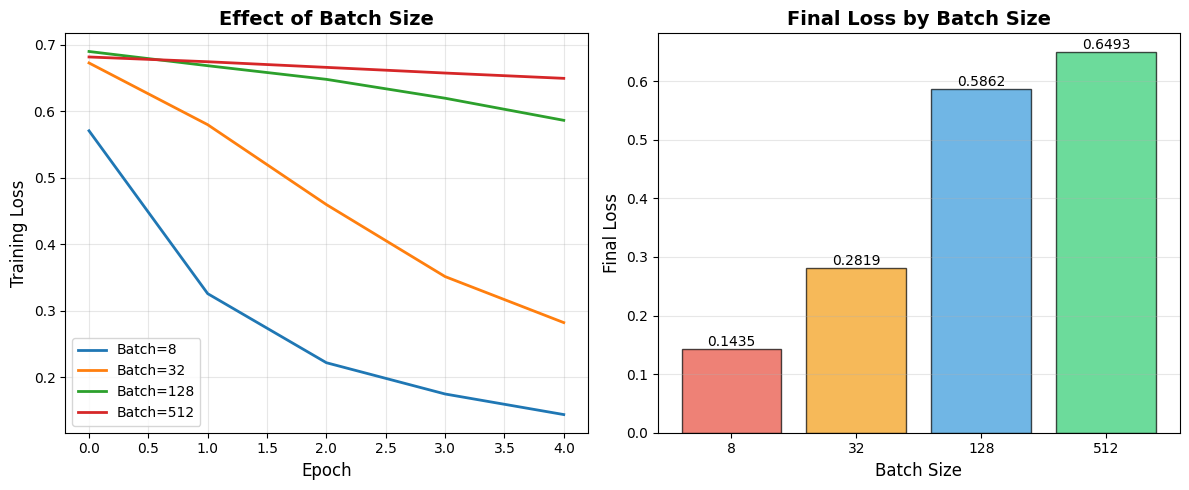


저장: batch_size_effect.png


In [43]:
# 시각화
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
for batch_size, losses in batch_size_results:
    plt.plot(losses, label=f'Batch={batch_size}', linewidth=2)

plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Training Loss', fontsize=12)
plt.title('Effect of Batch Size', fontsize=14, weight='bold')
plt.legend(fontsize=10)
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
final_losses = [losses[-1] for _, losses in batch_size_results]
colors = ['#e74c3c', '#f39c12', '#3498db', '#2ecc71']
bars = plt.bar([str(bs) for bs in batch_sizes], final_losses,
               color=colors, edgecolor='black', alpha=0.7)

plt.xlabel('Batch Size', fontsize=12)
plt.ylabel('Final Loss', fontsize=12)
plt.title('Final Loss by Batch Size', fontsize=14, weight='bold')
plt.grid(axis='y', alpha=0.3)

# 값 표시
for bar, loss in zip(bars, final_losses):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{loss:.4f}', ha='center', va='bottom', fontsize=10)


plt.tight_layout()
plt.show()
plt.savefig('batch_size_effect.png', dpi=150, bbox_inches='tight')
print("\n저장: batch_size_effect.png")
plt.close()

In [44]:
# BatchNorm 없는 네트워크 VS BatchNorm 있는 네트워크

class NetWithoutBN(nn.Module):
    """BatchNorm 없는 깊은 신경망"""
    def __init__(self):
        super(NetWithoutBN, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(20, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x)


class NetWithBN(nn.Module):
    """BatchNorm 있는 깊은 신경망"""
    def __init__(self):
        super(NetWithBN, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(20, 64),
            nn.BatchNorm1d(64),  # BatchNorm 추가
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x)

In [46]:
# 두 모델 학습
models_to_compare = [
    ('Without BN', NetWithoutBN()),
    ('With BN', NetWithBN())
]

comparison_results = []

batch_size = 32
dataset = TensorDataset(x_train_t, y_train_t)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

for model_name, model in models_to_compare:
  optimizer = optim.Adam(model.parameters(), lr=0.001)
  losses = []
  num_epochs = 5

  for epoch in range(num_epochs):
    epoch_loss = 0
    for batch_x, batch_y in dataloader:
        model.train()
        optimizer.zero_grad()

        output = model(batch_x)
        loss = criterion(output, batch_y)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(dataloader)
    losses.append(avg_loss)

    if (epoch + 1) % 10 == 0:
        print(f'epoch: {epoch+1}/{num_epochs} - Loss: {avg_loss:.3f} ')

  comparison_results.append((model_name, losses))


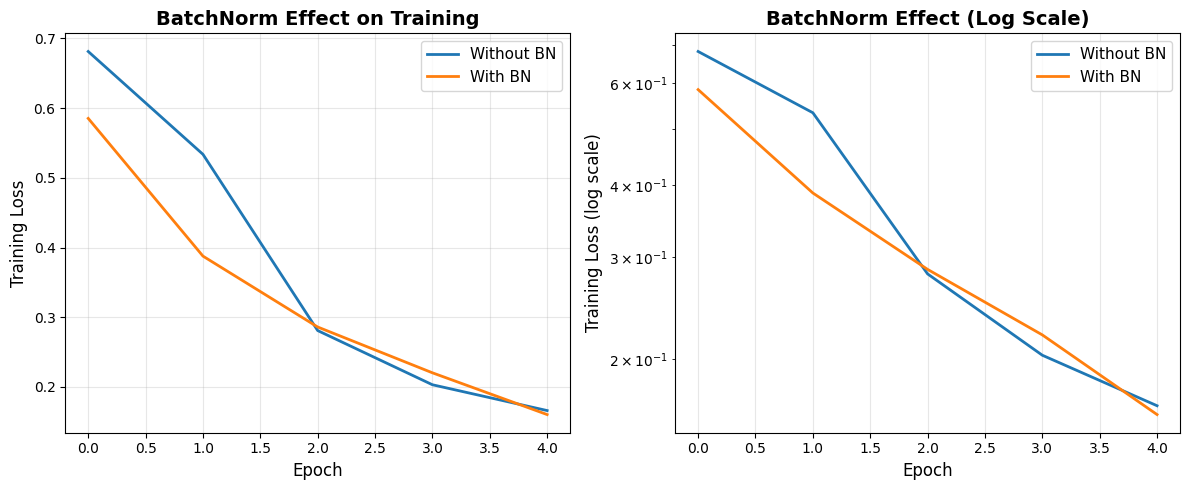


저장: batchnorm_effect.png


In [47]:
# 시각화
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
for model_name, losses in comparison_results:
    plt.plot(losses, label=model_name, linewidth=2)

plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Training Loss', fontsize=12)
plt.title('BatchNorm Effect on Training', fontsize=14, weight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
for model_name, losses in comparison_results:
    plt.plot(losses, label=model_name, linewidth=2)

plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Training Loss (log scale)', fontsize=12)
plt.title('BatchNorm Effect (Log Scale)', fontsize=14, weight='bold')
plt.yscale('log')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()
plt.savefig('batchnorm_effect.png', dpi=150, bbox_inches='tight')
print("\n저장: batchnorm_effect.png")
plt.close()

In [48]:
# BatchNorm 의 gradient 안정화 효과

# gradient 수집
grad_hist_without_bn = []
grad_hist_with_bn = []

# 새 모델 생성
model_without_bn = NetWithoutBN()
model_with_bn = NetWithBN()

# gradient 기록 (hook)

def create_gradient_hook(gradient_list):
    # gradient 를 리스트에 저장하는 hook 생성
    def hook(grad):
        gradient_list.append(grad.abs().mean().item())
        return grad
    return hook

# without bn
for name, param in model_without_bn.named_parameters():
    if 'weight' in name:
        param.register_hook(create_gradient_hook(grad_hist_without_bn))

# with bn
for name, param in model_with_bn.named_parameters():
    if 'weight' in name:
        param.register_hook(create_gradient_hook(grad_hist_with_bn))

batch_X = x_train_t[:32] # 배치크기 32
batch_y = y_train_t[:32]

# without bn
output_without = model_without_bn(batch_X)
loss_without = criterion(output_without, batch_y)
loss_without.backward()

# with bn
output_with = model_with_bn(batch_X)
loss_with = criterion(output_with, batch_y)
loss_with.backward()

# gradient 역순 정렬 (layer1부터 표시)
grad_hist_without_bn.reverse()
grad_hist_with_bn.reverse()

# 각 층의 gradient 크기

print("Without BN")
for i, grad in enumerate(grad_hist_without_bn):
    print(f' Layer {i+1}: {grad:.4f}')

print("With BN")
for i, grad in enumerate(grad_hist_with_bn):
    print(f' Layer {i+1}: {grad:.4f}')

Without BN
 Layer 1: 0.0003
 Layer 2: 0.0003
 Layer 3: 0.0002
 Layer 4: 0.0005
 Layer 5: 0.0077
With BN
 Layer 1: 0.0102
 Layer 2: 0.0045
 Layer 3: 0.0087
 Layer 4: 0.0038
 Layer 5: 0.0065
 Layer 6: 0.0035
 Layer 7: 0.0071
 Layer 8: 0.0057
 Layer 9: 0.0736


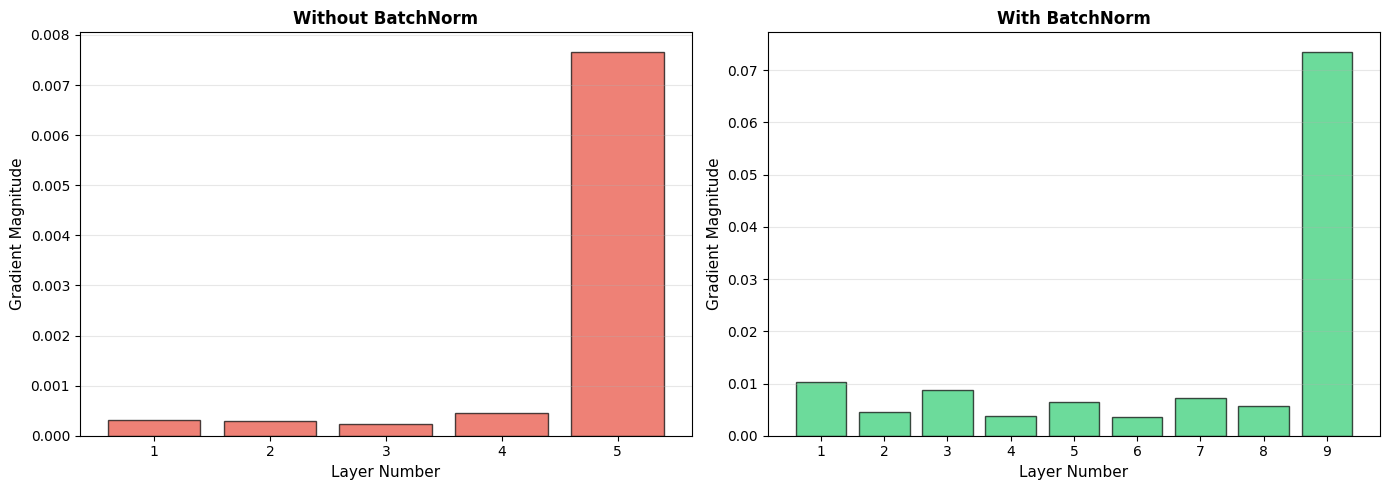


저장: part5_gradient_stability.png

분석:
  - BatchNorm 없음: 층마다 그래디언트 크기 차이가 큼
  - BatchNorm 있음: 적어도 8개 층까지는 유사하게 그래디언트가 비슷한 크기
  - 결과: 더 안정적인 학습 가능


In [49]:
# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Without BN
ax1 = axes[0]
layers = list(range(1, len(grad_hist_without_bn) + 1))
ax1.bar(layers, grad_hist_without_bn, color='#e74c3c',
        edgecolor='black', alpha=0.7)
ax1.set_xlabel('Layer Number', fontsize=11)
ax1.set_ylabel('Gradient Magnitude', fontsize=11)
ax1.set_title('Without BatchNorm', fontsize=12, weight='bold')
ax1.set_xticks(layers)
ax1.grid(axis='y', alpha=0.3)

# With BN
ax2 = axes[1]
layers = list(range(1, len(grad_hist_with_bn) + 1))
ax2.bar(layers, grad_hist_with_bn, color='#2ecc71',
        edgecolor='black', alpha=0.7)
ax2.set_xlabel('Layer Number', fontsize=11)
ax2.set_ylabel('Gradient Magnitude', fontsize=11)
ax2.set_title('With BatchNorm', fontsize=12, weight='bold')
ax2.set_xticks(layers)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()
plt.savefig('part5_gradient_stability.png', dpi=150, bbox_inches='tight')
print("\n저장: part5_gradient_stability.png")
plt.close()

print("\n분석:")
print("  - BatchNorm 없음: 층마다 그래디언트 크기 차이가 큼")
print("  - BatchNorm 있음: 적어도 8개 층까지는 유사하게 그래디언트가 비슷한 크기")
print("  - 결과: 더 안정적인 학습 가능")

In [50]:
# batch size에서 BatchNorm 효과

batch_sizes_test = [8, 16, 32, 64]

results_comparison = {}

for batch_size in batch_sizes_test:
    dataset = TensorDataset(x_train_t, y_train_t)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    # without bn
    model_no_bn = NetWithoutBN()
    optimizer_no_bn = optim.Adam(model_no_bn.parameters(), lr=0.001)

    losses_no_bn = []

    for epoch in range(5):
        epoch_loss = 0
        for batch_X, batch_y in dataloader:
            model_no_bn.train()
            optimizer_no_bn.zero_grad()

            output = model_no_bn(batch_X)
            loss = criterion(output, batch_y)
            loss.backward()
            optimizer_no_bn.step()

            epoch_loss += loss.item()
        losses_no_bn.append(epoch_loss / len(dataloader))

    # with bn
    model_with_bn = NetWithBN()
    optimizer_with_bn = optim.Adam(model_with_bn.parameters(), lr=0.001)

    losses_with_bn = []

    for epoch in range(5):
        epoch_loss = 0
        for batch_X, batch_y in dataloader:
            model_with_bn.train()
            optimizer_with_bn.zero_grad()

            output = model_with_bn(batch_X)
            loss = criterion(output, batch_y)
            loss.backward()
            optimizer_with_bn.step()

            epoch_loss += loss.item()
        losses_with_bn.append(epoch_loss / len(dataloader))

    results_comparison[batch_size] = {
        'without_bn': losses_no_bn,
        'with_bn': losses_with_bn
    }

    print(f' without bn 최종 손실: {losses_no_bn[-1]:.4f}')
    print(f' with bn 최종 손실: {losses_with_bn[-1]:.4f}')


 without bn 최종 손실: 0.0748
 with bn 최종 손실: 0.2947
 without bn 최종 손실: 0.1037
 with bn 최종 손실: 0.1931
 without bn 최종 손실: 0.1449
 with bn 최종 손실: 0.1734
 without bn 최종 손실: 0.2438
 with bn 최종 손실: 0.2344


## 핵심 시사점

BatchNorm은 배치 크기가 충분히 커야 제 성능을 발휘합니다 (보통 실무에서도 32 이상을 권장하는 경우가 많음)
배치 크기가 아주 작은 상황(메모리 제약, 온라인 학습 등)에서는 BatchNorm 대신 LayerNorm, GroupNorm, InstanceNorm 같은 배치 크기에 덜 민감한 정규화 기법을 쓰는 게 낫다는 결론으로 이어짐
"BatchNorm을 쓰면 무조건 좋다"가 아니라 **"배치 크기라는 전제 조건이 맞아야 좋다"**는 걸 실험적으로 보여주는 코드예요

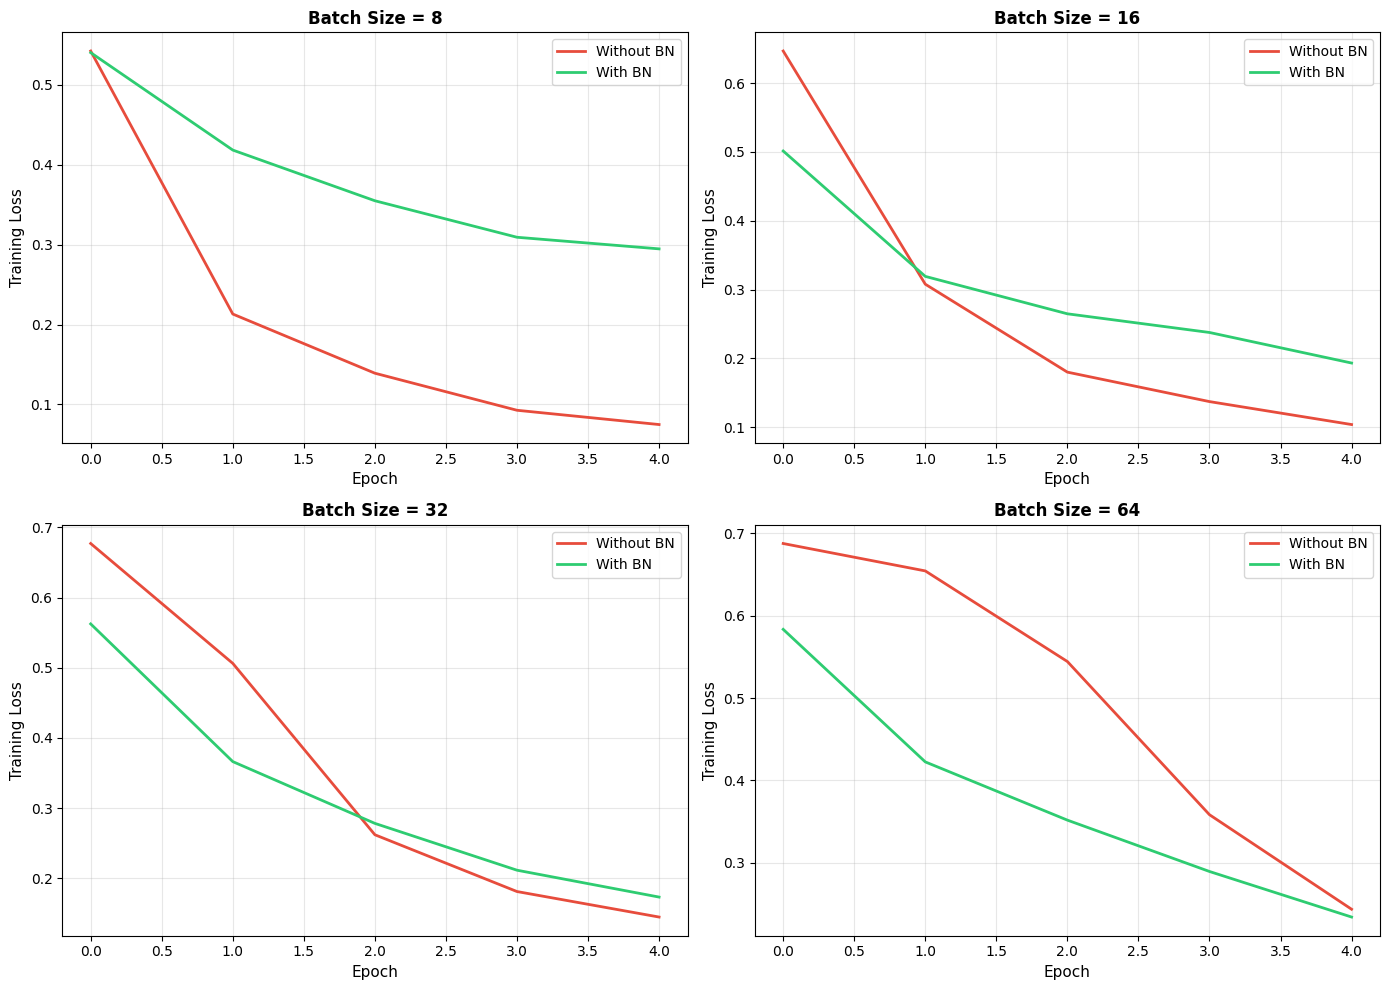


저장: part5_batchnorm_various_batch_sizes.png


In [51]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, batch_size in enumerate(batch_sizes_test):
    ax = axes[idx // 2, idx % 2]

    losses_no_bn = results_comparison[batch_size]['without_bn']
    losses_with_bn = results_comparison[batch_size]['with_bn']

    ax.plot(losses_no_bn, label='Without BN', linewidth=2, color='#e74c3c')
    ax.plot(losses_with_bn, label='With BN', linewidth=2, color='#2ecc71')

    ax.set_xlabel('Epoch', fontsize=11)
    ax.set_ylabel('Training Loss', fontsize=11)
    ax.set_title(f'Batch Size = {batch_size}', fontsize=12, weight='bold')
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()
plt.savefig('part5_batchnorm_various_batch_sizes.png', dpi=150, bbox_inches='tight')
print("\n저장: part5_batchnorm_various_batch_sizes.png")
plt.close()

In [ ]:
# 결론 : 배치사이즈가 클수록 정확(batch_normalization 중요, 평균과 분산 사용하기 때문에 )